<a href="https://colab.research.google.com/github/javisagredo-dev/Evaluacion2_Prog_DS/blob/main/03_aprendizaje_supervisado(optimizado).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aprendizaje supervisado: optimización de hiperparámetros

## Importaciones necesarias

In [1]:
import pickle
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time
import warnings
warnings.filterwarnings('ignore')

## Carga y lectura de datos

In [2]:
drive.mount('/content/drive')
df = pd.read_excel('/content/drive/MyDrive/Ciencia de Datos Collab/Programación para la ciencia de datos/Evaluacion_2/Raw/Dry_Bean_Dataset.xlsx')

Mounted at /content/drive


## Preparación de datos para optimización de hiperparámetros

In [3]:
df_model = df.copy()

X = df_model.drop('Class', axis=1)
le = LabelEncoder()
y = le.fit_transform(df_model['Class'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Carga de las variables guardadas

In [5]:
ruta_pkl = "/content/drive/MyDrive/Ciencia de Datos Collab/Programación para la ciencia de datos/Evaluacion_2/Processed/resultados_modelos.pkl"

with open(ruta_pkl, 'rb') as f:
    datos = pickle.load(f)

accuracy_dt = datos['accuracy_dt']
accuracy_lr = datos['accuracy_lr']
accuracy_svm = datos['accuracy_svm']
f1_dt = datos['f1_dt']
f1_lr = datos['f1_lr']
f1_svm = datos['f1_svm']
y_pred_dt = datos['y_pred_dt']
y_pred_lr = datos['y_pred_lr']
y_pred_svm = datos['y_pred_svm']
y_test = datos['y_test']
le = datos['le']

print("Variables importadas correctamente")

Variables importadas correctamente


## GridSearchCV - Optimización de Árbol de Decisión

In [6]:
param_grid_dt = {
    'max_depth': [7, 8, 9, 10],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

start_time = time.time()
grid_dt.fit(X_train, y_train)
time_grid_dt = time.time() - start_time

print(f" Tiempo: {time_grid_dt:.2f} segundos")
print(f" Mejores hiperparámetros: {grid_dt.best_params_}")
print(f" Mejor accuracy (cv): {grid_dt.best_score_:.4f}")

y_pred_grid_dt = grid_dt.predict(X_test)
print(f" Accuracy en test: {accuracy_score(y_test, y_pred_grid_dt):.4f}")

 Tiempo: 20.40 segundos
 Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 10}
 Mejor accuracy (cv): 0.9082
 Accuracy en test: 0.9071


## GridSearchCV - Optimización de Regresión Logística

In [7]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [1000]
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

start_time = time.time()
grid_lr.fit(X_train_scaled, y_train)
time_grid_lr = time.time() - start_time

print(f" Tiempo: {time_grid_lr:.2f} segundos")
print(f" Mejores hiperparámetros: {grid_lr.best_params_}")
print(f" Mejor accuracy (cv): {grid_lr.best_score_:.4f}")

y_pred_grid_lr = grid_lr.predict(X_test_scaled)
print(f" Accuracy en test: {accuracy_score(y_test, y_pred_grid_lr):.4f}")

 Tiempo: 94.87 segundos
 Mejores hiperparámetros: {'C': 100, 'max_iter': 1000, 'solver': 'lbfgs'}
 Mejor accuracy (cv): 0.9257
 Accuracy en test: 0.9196


## GridSearchCV - Optimización de SVM

In [8]:
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

start_time = time.time()
grid_svm.fit(X_train_scaled, y_train)
time_grid_svm = time.time() - start_time

print(f" Tiempo: {time_grid_svm:.2f} segundos")
print(f" Mejores hiperparámetros: {grid_svm.best_params_}")
print(f" Mejor accuracy (cv): {grid_svm.best_score_:.4f}")

y_pred_grid_svm = grid_svm.predict(X_test_scaled)
print(f" Accuracy en test: {accuracy_score(y_test, y_pred_grid_svm):.4f}")

 Tiempo: 26.16 segundos
 Mejores hiperparámetros: {'C': 10, 'kernel': 'rbf'}
 Mejor accuracy (cv): 0.9331
 Accuracy en test: 0.9243


## Comparación final: modelos base vs optimizados

In [9]:
comparison_final = pd.DataFrame({
    'Modelo': ['Árbol de Decisión', 'Regresión Logística', 'SVM'],
    'Accuracy antes': [accuracy_dt, accuracy_lr, accuracy_svm],
    'Accuracy después': [
        accuracy_score(y_test, y_pred_grid_dt),
        accuracy_score(y_test, y_pred_grid_lr),
        accuracy_score(y_test, y_pred_grid_svm)
    ],
    'Mejora': [
        accuracy_score(y_test, y_pred_grid_dt) - accuracy_dt,
        accuracy_score(y_test, y_pred_grid_lr) - accuracy_lr,
        accuracy_score(y_test, y_pred_grid_svm) - accuracy_svm
    ]
})

print(comparison_final.to_string(index=False))

best = comparison_final.loc[comparison_final['Accuracy después'].idxmax()]
print(f"\n{'='*60}")
print(f"MEJOR MODELO FINAL: {best['Modelo']}")
print(f"Accuracy: {best['Accuracy después']:.4f}")
print(f"{'='*60}")

             Modelo  Accuracy antes  Accuracy después    Mejora
  Árbol de Decisión        0.907088          0.907088  0.000000
Regresión Logística        0.921410          0.919574 -0.001836
                SVM        0.922145          0.924348  0.002203

MEJOR MODELO FINAL: SVM
Accuracy: 0.9243


## Gráfico comparativo: Antes vs Después de optimización (Accuracy)

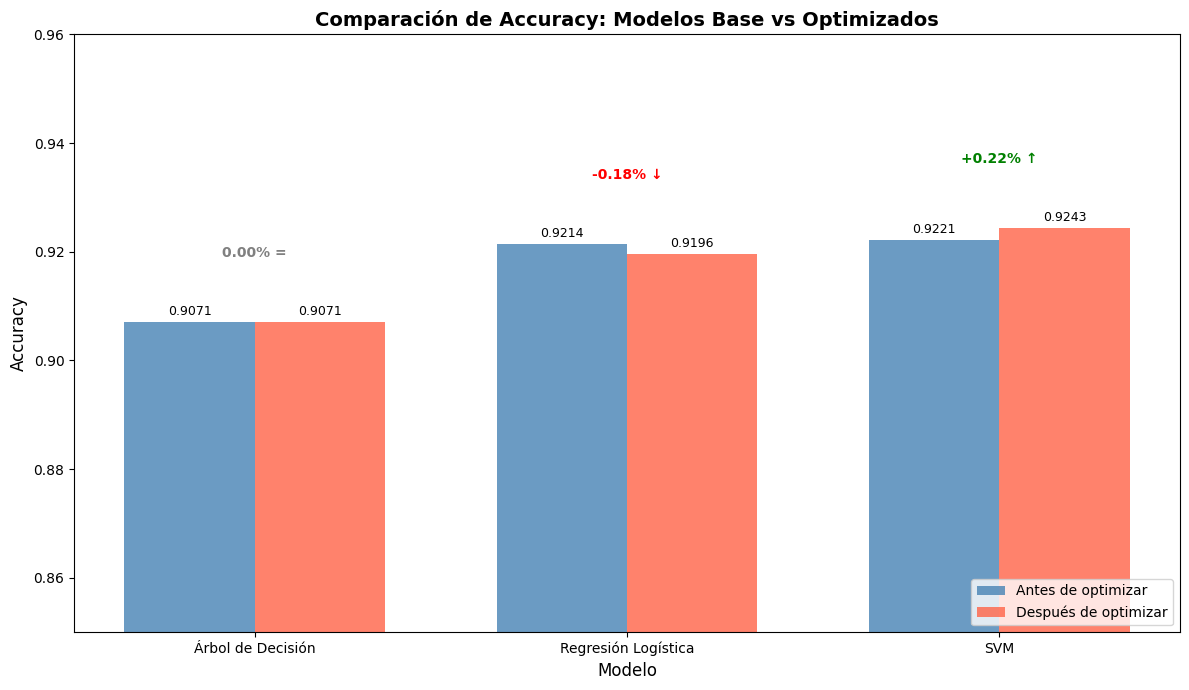

In [10]:

modelos = ['Árbol de Decisión', 'Regresión Logística', 'SVM']
accuracy_antes = [accuracy_dt, accuracy_lr, accuracy_svm]
accuracy_despues = [
    accuracy_score(y_test, y_pred_grid_dt),
    accuracy_score(y_test, y_pred_grid_lr),
    accuracy_score(y_test, y_pred_grid_svm)
]

x = np.arange(len(modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(x - width/2, accuracy_antes, width, label='Antes de optimizar', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, accuracy_despues, width, label='Después de optimizar', color='tomato', alpha=0.8)


ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Comparación de Accuracy: Modelos Base vs Optimizados', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.legend(loc='lower right')
ax.set_ylim([0.85, 0.96])


for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)


for i, (antes, despues) in enumerate(zip(accuracy_antes, accuracy_despues)):
    mejora = (despues - antes) * 100
    if mejora > 0:
        color = 'green'
        signo = '+'
        texto = f'{signo}{mejora:.2f}% ↑'
    elif mejora < 0:
        color = 'red'
        signo = ''
        texto = f'{signo}{mejora:.2f}% ↓'
    else:
        color = 'gray'
        texto = '0.00% ='


    ax.annotate(texto,
                xy=(i, max(antes, despues) + 0.012),
                ha='center', fontsize=10, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

## Gráfico comparativo: Antes vs Después de optimización (F1-Score)

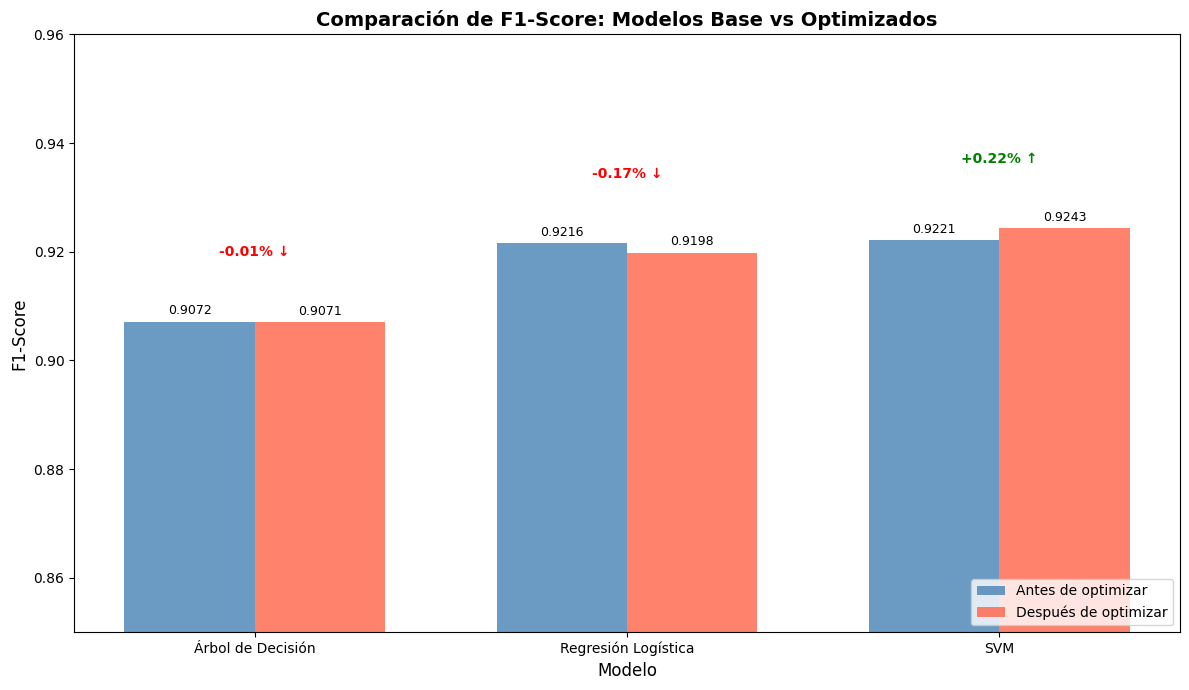

In [11]:
modelos = ['Árbol de Decisión', 'Regresión Logística', 'SVM']
f1_antes = [f1_dt, f1_lr, f1_svm]
f1_despues = [
    f1_score(y_test, y_pred_grid_dt, average='weighted'),
    f1_score(y_test, y_pred_grid_lr, average='weighted'),
    f1_score(y_test, y_pred_grid_svm, average='weighted')
]

x = np.arange(len(modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(x - width/2, f1_antes, width, label='Antes de optimizar', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, f1_despues, width, label='Después de optimizar', color='tomato', alpha=0.8)


ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Comparación de F1-Score: Modelos Base vs Optimizados', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.legend(loc='lower right')
ax.set_ylim([0.85, 0.96])


for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)


for i, (antes, despues) in enumerate(zip(f1_antes, f1_despues)):
    mejora = (despues - antes) * 100
    if mejora > 0:
        color = 'green'
        signo = '+'
        texto = f'{signo}{mejora:.2f}% ↑'
    elif mejora < 0:
        color = 'red'
        signo = ''
        texto = f'{signo}{mejora:.2f}% ↓'
    else:
        color = 'gray'
        texto = '0.00% ='


    ax.annotate(texto,
                xy=(i, max(antes, despues) + 0.012),
                ha='center', fontsize=10, fontweight='bold', color=color)

plt.tight_layout()
plt.show()